# 🏠 House Price Prediction — Exploratory Data Analysis
## Objectif
Explorer le dataset Ames Housing pour comprendre la structure des données, 
les distributions, les valeurs manquantes et les relations entre variables.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Afficher les graphiques dans le notebook
%matplotlib inline

# Charger les données
df = pd.read_csv('../data/train.csv')

# Afficher les premières lignes
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [2]:
# Dimensions du dataset
print("Nombre de maisons :", df.shape[0])
print("Nombre de variables :", df.shape[1])

Nombre de maisons : 1460
Nombre de variables : 81


In [3]:
# Types des variables et valeurs manquantes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [4]:
# Analyse des valeurs manquantes
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


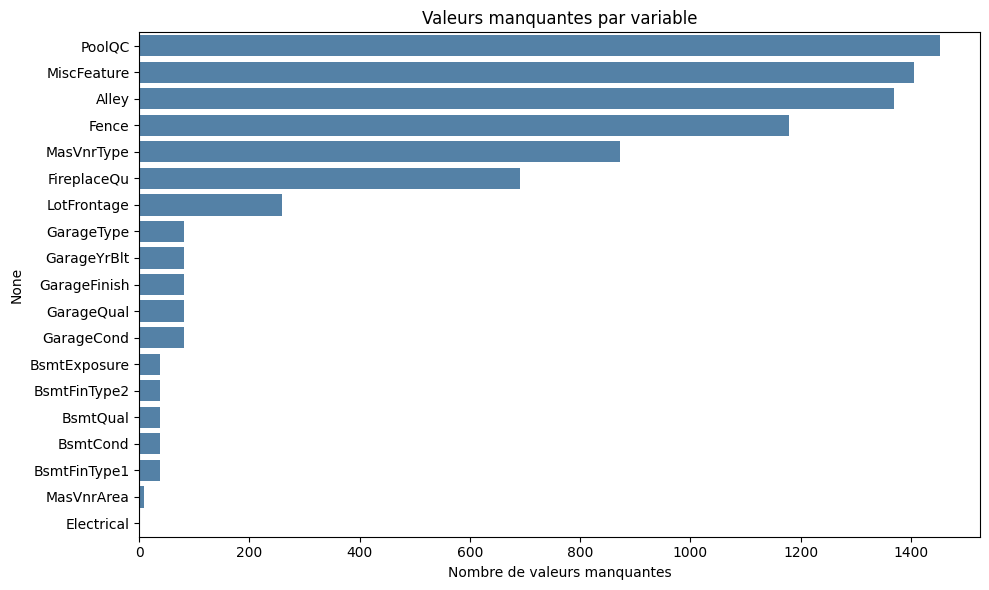

In [5]:
# Visualisation des valeurs manquantes
plt.figure(figsize=(10, 6))
sns.barplot(x=missing.values, y=missing.index, color='steelblue')
plt.title('Valeurs manquantes par variable')
plt.xlabel('Nombre de valeurs manquantes')
plt.tight_layout()
plt.show()

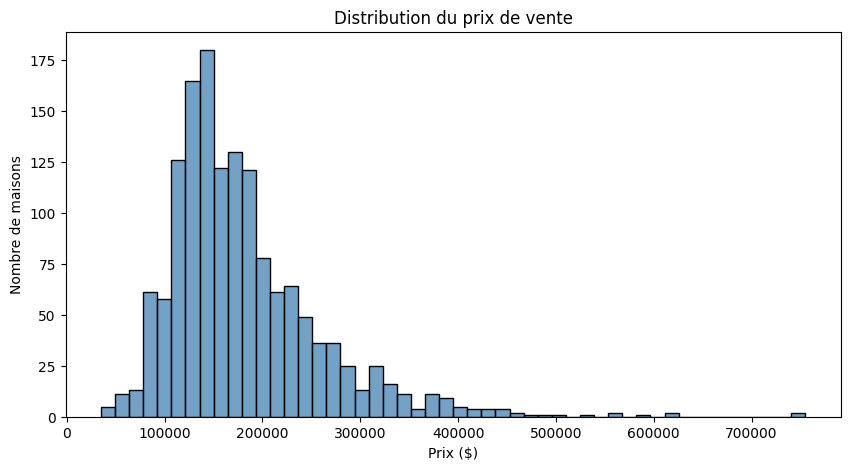

In [6]:
# Distribution du prix de vente
plt.figure(figsize=(10, 5))
sns.histplot(df['SalePrice'], bins=50, color='steelblue')
plt.title('Distribution du prix de vente')
plt.xlabel('Prix ($)')
plt.ylabel('Nombre de maisons')
plt.show()

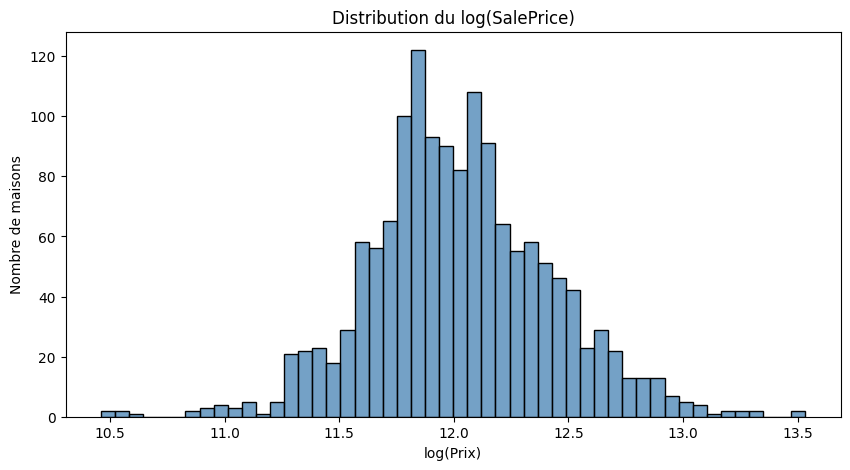

In [7]:
# Distribution après transformation logarithmique
plt.figure(figsize=(10, 5))
sns.histplot(np.log(df['SalePrice']), bins=50, color='steelblue')
plt.title('Distribution du log(SalePrice)')
plt.xlabel('log(Prix)')
plt.ylabel('Nombre de maisons')
plt.show()

In [8]:
# Corrélation avec SalePrice
correlation = df.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)
print(correlation.head(11))

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64


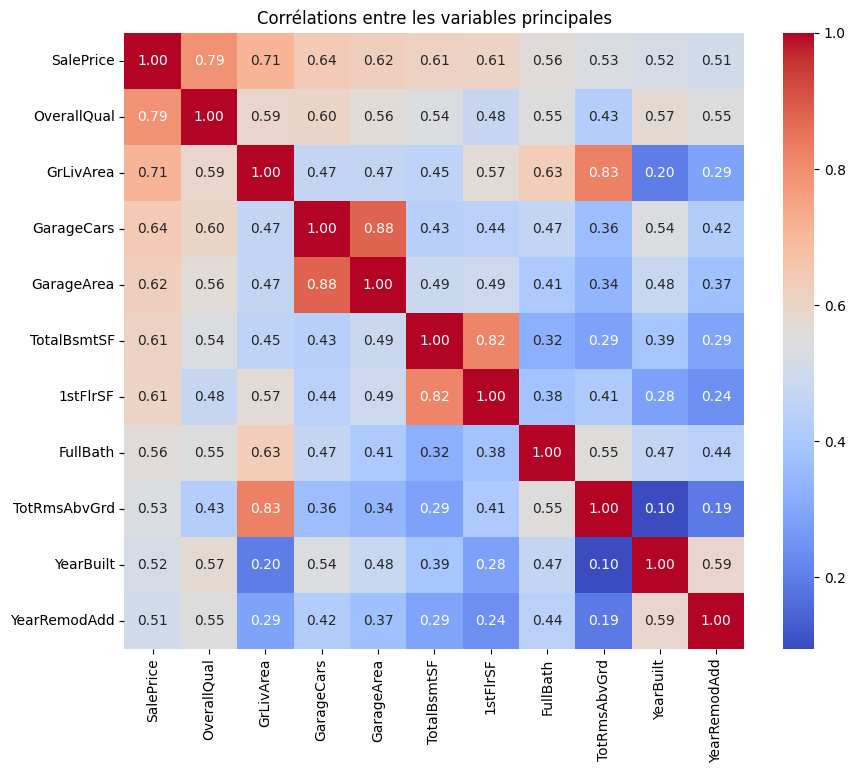

In [9]:
# Heatmap des corrélations
top_features = correlation.head(11).index
plt.figure(figsize=(10, 8))
sns.heatmap(df[top_features].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Corrélations entre les variables principales')
plt.show()

C:\Users\amine\AppData\Local\Temp\ipykernel_10192\228455580.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='OverallQual', y='SalePrice', data=df, palette='coolwarm')


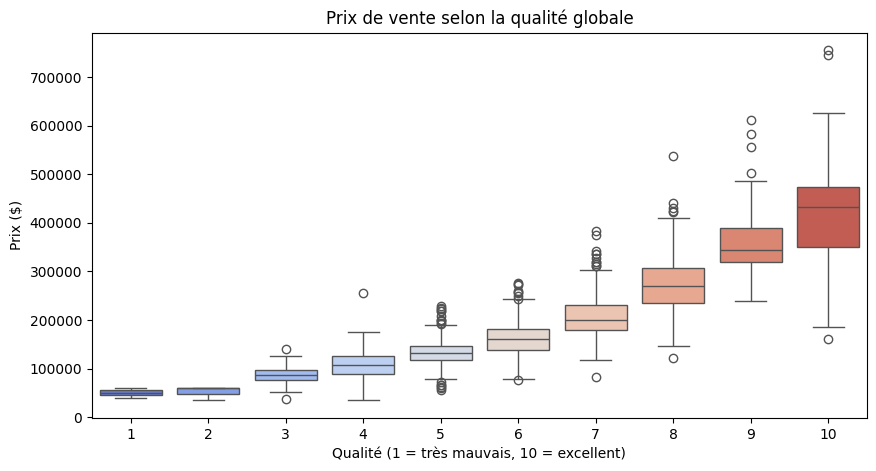

In [10]:
# Prix selon la qualité globale
plt.figure(figsize=(10, 5))
sns.boxplot(x='OverallQual', y='SalePrice', data=df, palette='coolwarm')
plt.title('Prix de vente selon la qualité globale')
plt.xlabel('Qualité (1 = très mauvais, 10 = excellent)')
plt.ylabel('Prix ($)')
plt.show()

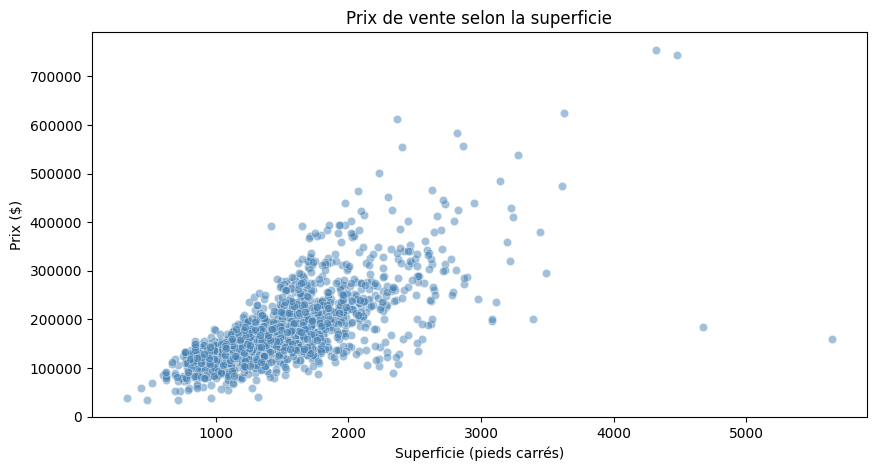

In [11]:
# Relation entre superficie et prix
plt.figure(figsize=(10, 5))
sns.scatterplot(x='GrLivArea', y='SalePrice', data=df, alpha=0.5, color='steelblue')
plt.title('Prix de vente selon la superficie')
plt.xlabel('Superficie (pieds carrés)')
plt.ylabel('Prix ($)')
plt.show()

C:\Users\amine\AppData\Local\Temp\ipykernel_10192\3924361907.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=neighborhood_price.index, y=neighborhood_price.values, palette='coolwarm')


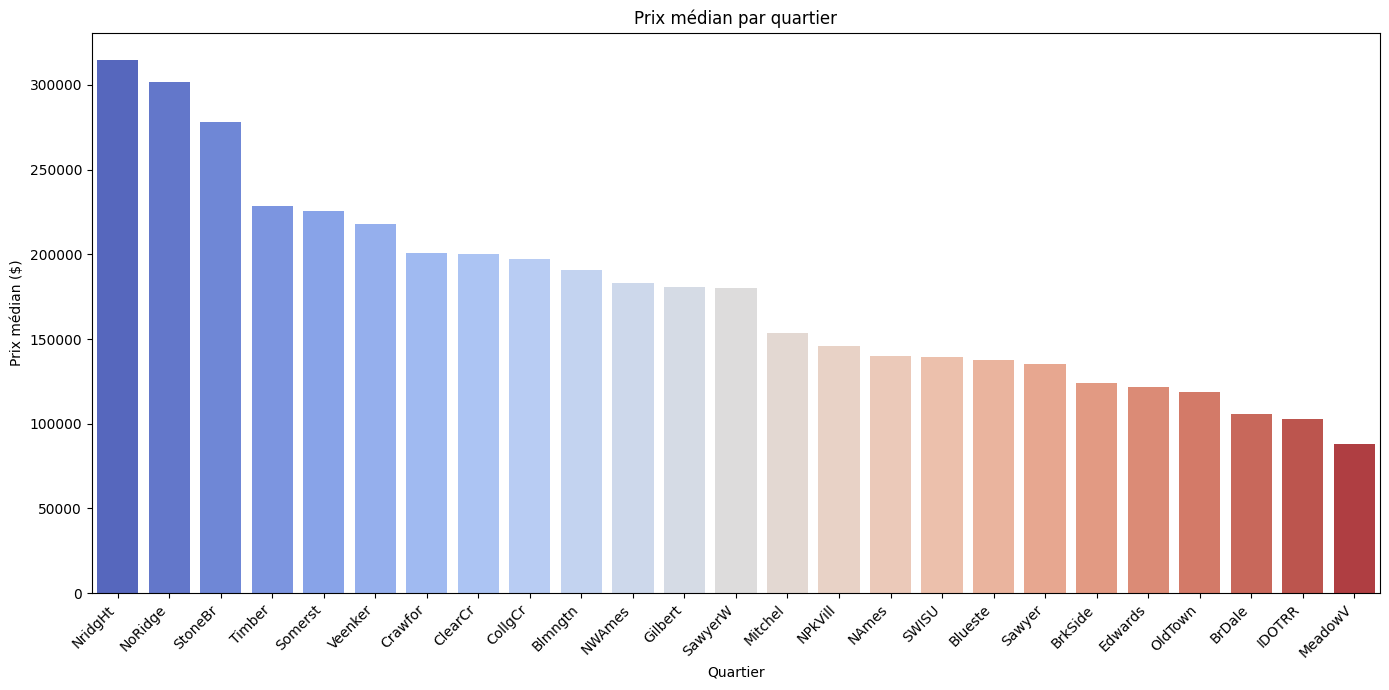

In [13]:
# Prix par quartier
plt.figure(figsize=(14, 7))
neighborhood_price = df.groupby('Neighborhood')['SalePrice'].median().sort_values(ascending=False)
sns.barplot(x=neighborhood_price.index, y=neighborhood_price.values, palette='coolwarm')
plt.title('Prix médian par quartier')
plt.xlabel('Quartier')
plt.ylabel('Prix médian ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()